# Tarea 1 Inteligencia Artificial - Parte 1
### Red Bayesiana

**Integrantes:** Magdalena Correa - Martin Melo

**Dataset:** Diabetes 130-US Hospitals for Years 1999-2008 (UCI 296)

**Variable objetivo:** *readmitted*


In [1]:
import os, random, numpy as np
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)

## 1. Carga y exploración inicial del conjunto de datos

In [2]:
import pandas as pd, numpy as np, matplotlib
import pgmpy, hmmlearn

print("pgmpy", pgmpy.__version__, "| hmmlearn", hmmlearn.__version__)

df = pd.read_csv("Dataset/energydata_complete.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

pgmpy 1.1.2 | hmmlearn 0.3.3
(19735, 29)
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("Dataset/diabetic_data.csv", na_values="?")
print(df1.shape)
df1.head()

(101766, 50)


C:\Users\Marti\AppData\Local\Temp\ipykernel_22644\1883014046.py:4: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("Dataset/diabetic_data.csv", na_values="?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [5]:
df1.nunique().sort_values()

citoglipton                      1
examide                          1
acetohexamide                    2
glipizide-metformin              2
tolbutamide                      2
troglitazone                     2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
metformin-pioglitazone           2
change                           2
diabetesMed                      2
gender                           3
tolazamide                       3
readmitted                       3
max_glu_serum                    3
A1Cresult                        3
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
miglitol                         4
glimepiride                      4
metformin                        4
nateglinide                      4
repaglinide                      4
chlorpropamide                   4
glipizide                        4
glyburide                        4
insulin                          4
glyburide-metformin 

In [6]:
faltantes = df1.isna().sum()
(faltantes[faltantes > 0] / len(df1) * 100).sort_values(ascending=False).round(2)

weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64

In [7]:
for col in df1.columns:
    top = df1[col].value_counts(normalize=True, dropna=False).head(1)
    if top.iloc[0] > 0.95:
        print(f"{col:35s} {top.index[0]!s:20s} {top.iloc[0]:.1%}")

weight                              nan                  96.9%
repaglinide                         No                   98.5%
nateglinide                         No                   99.3%
chlorpropamide                      No                   99.9%
acetohexamide                       No                   100.0%
tolbutamide                         No                   100.0%
acarbose                            No                   99.7%
miglitol                            No                   100.0%
troglitazone                        No                   100.0%
tolazamide                          No                   100.0%
examide                             No                   100.0%
citoglipton                         No                   100.0%
glyburide-metformin                 No                   99.3%
glipizide-metformin                 No                   100.0%
glimepiride-pioglitazone            No                   100.0%
metformin-rosiglitazone             No        

### 1.1 Diagnóstico automatico de columnas

La siguiente celda resume el tipo, la cardinalidad, el porcentaje de valores faltantes y el peso de la clase mayoritaria para cada columna. Estas cifras constituyen la base para la selección de columnas útiles, la cual se detalla más abajo.

In [8]:
import pandas as pd, numpy as np
pd.set_option("display.max_rows", 100)

df1 = pd.read_csv("Dataset/diabetic_data.csv", na_values="?")

filas = []
for col in df1.columns:
    vc = df1[col].value_counts(normalize=True, dropna=False)
    filas.append({
        "columna": col,
        "tipo": str(df1[col].dtype),
        "n_unicos": int(df1[col].nunique(dropna=True)),
        "%_faltantes": round(df1[col].isna().mean() * 100, 2),
        "%_clase_mayoritaria": round(vc.iloc[0] * 100, 2),
        "valor_mayoritario": str(vc.index[0])[:20],
    })

diagnostico = pd.DataFrame(filas)

def marcar(r):
    if r["%_faltantes"] > 40:            return "faltantes >40%"
    if r["%_clase_mayoritaria"] > 95:    return "casi constante"
    if r["n_unicos"] > 100 and r["tipo"] == "object": return "cardinalidad alta"
    if r["n_unicos"] <= 1:               return "constante"
    return "candidata"

diagnostico["alerta"] = diagnostico.apply(marcar, axis=1)
print(diagnostico.sort_values(["alerta", "columna"]).to_string(index=False))
print("\nResumen de alertas:")
print(diagnostico["alerta"].value_counts())
print("\nDistribucion de la variable objetivo:")
print(df1["readmitted"].value_counts(normalize=True).round(4))
print("\nFilas totales:", len(df1), "| pacientes unicos:", df1["patient_nbr"].nunique())

C:\Users\Marti\AppData\Local\Temp\ipykernel_22644\227585636.py:4: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("Dataset/diabetic_data.csv", na_values="?")


                 columna  tipo  n_unicos  %_faltantes  %_clase_mayoritaria valor_mayoritario         alerta
     admission_source_id int64        17         0.00                56.50                 7      candidata
       admission_type_id int64         8         0.00                53.05                 1      candidata
                     age   str        10         0.00                25.62           [70-80)      candidata
                  change   str         2         0.00                53.80                No      candidata
             diabetesMed   str         2         0.00                77.00               Yes      candidata
                  diag_1   str       716         0.02                 6.74               428      candidata
                  diag_2   str       748         0.35                 6.63               276      candidata
                  diag_3   str       789         1.40                11.35               250      candidata
discharge_disposition_id int

In [9]:
col = "weight"
print(df1[col].value_counts(dropna=False))
print()
print(df1[col].describe())

weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

count         3197
unique           9
top       [75-100)
freq          1336
Name: weight, dtype: object


In [10]:
mapping = pd.read_csv("Dataset/IDS_mapping.csv")
mapping.head(50)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


### 1.2 Análisis de columnas

El conjunto original contiene 101.766 registros y 50 columnas. No todas son utilizables para una red bayesiana, por lo que se aplicaron cuatro criterios de descarte, apoyados en la tabla de diagnóstico de la sección anterior.

- **Identificadores:** 

*encounter_id* y *patient_nbr* son claves con 101.766 y 71.518 valores distintos, respectivamente. No representan ninguna magnitud clínica y su elevada cardinalidad haría imposible estimar las tablas de probabilidad condicional.

- **Alta proporción de valores faltantes:** 

Se descartan *weight* (96,9% de faltantes), *max_glu_serum* (95,2%), *medical_specialty* (49,1%) y *payer_code* (39,6%). En el caso de *weight*, la información disponible cubre apenas 3.197 registros, lo cual es insuficiente para estimar dependencias. Por su parte, *max_glu_serum* se descarta aunque su ausencia sea informativa, ya que el 4,8% de los casos presentes se reparte en tres niveles y ninguno alcanza el tamaño muestral requerido.

- **Variables casi constantes:** 

Diecisiete columnas de medicamentos (*acetohexamide*, *tolbutamide*, *troglitazone*, *examide*, *citoglipton*, *metformin-pioglitazone*, entre otras) presentan el valor "No" en más del 98% de los registros, e incluso varias de ellas en el 100%. Una variable sin variabilidad no aporta información condicional, ya que su distribución es prácticamente independiente de cualquier otra. Se conservan únicamente *insulin*, *change* y *diabetesMed*, las cuales sí presentan distribuciones balanceadas.

- **Alta cardinalidad y redundancia semántica:** 

*diag_2* y *diag_3* tienen 748 y 789 códigos ICD-9 distintos. Se descartan por redundancia con *diag_1*, el cual recoge el diagnóstico principal y se agrupa en capítulos ICD-9 para reducir su cardinalidad de 716 a 10 niveles.

- **Filtrado de registros:** 

Se conserva únicamente el primer encuentro de cada paciente, identificado por el menor *encounter_id* dentro de cada *patient_nbr*. Con esto se pasa de 101.766 a 71.518 filas. Adicionalmente, se descartan los tres registros con género no válido y los egresos por fallecimiento u hospicio, en los cuales la readmisión es imposible por definición. El conjunto final cuenta con **69.970 filas y 20 variables útiles**, cumpliendo el mínimo de 8.000 filas y 12 columnas.

- **Variable objetivo:** 

Se elige *readmitted*, la cual clasifica al paciente en tres estados: readmitido antes de 30 días (9%), readmitido después de 30 días (31,8%) y no readmitido (59,3%). Es una variable relevante porque la readmisión temprana es un indicador de calidad asistencial utilizado por Medicare para penalizar hospitales, y porque no es una consecuencia determinista de ninguna otra columna, sino el resultado de la interacción entre el estado clínico del paciente, la intensidad del tratamiento recibido y el destino al egreso. Su distribución en tres clases desbalanceadas, pero no degeneradas, la hace adecuada para la inferencia probabilística.

## 2. Preprocesamiento y discretización

Las variables numéricas se llevan a categorías porque *DiscreteBayesianNetwork*
de pgmpy trabaja únicamente con variables discretas. Los diagnósticos ICD-9 se
agrupan en capitulos para reducir su cardinalidad.

In [11]:
# Revision de cortes: cuantiles y frecuencias reales antes de discretizar
NUMERICAS = ["time_in_hospital", "num_lab_procedures", "num_procedures",
             "num_medications", "number_diagnoses", "number_outpatient",
             "number_emergency", "number_inpatient"]

prev = (df1.sort_values("encounter_id")
           .drop_duplicates("patient_nbr", keep="first"))
prev = prev[prev["gender"].isin(["Male", "Female"])]
prev = prev[~prev["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])]
print("Filas tras deduplicar y filtrar:", len(prev))

print("\n=== Cuantiles de las variables numericas ===")
print(prev[NUMERICAS]
      .describe(percentiles=[.1, .25, .33, .5, .66, .75, .9])
      .T.round(2).to_string())

print("\n=== Proporcion de ceros ===")
print((prev[NUMERICAS] == 0).mean().round(3).to_string())

print("\n=== Distribucion de readmitted ===")
print(prev["readmitted"].value_counts(normalize=True).round(4).to_string())

for col in ["admission_type_id", "admission_source_id", "discharge_disposition_id"]:
    print(f"\n=== {col} (12 valores mas frecuentes) ===")
    print(prev[col].value_counts().head(12).to_string())

print("\n=== Categoricas de manejo de diabetes ===")
for col in ["A1Cresult", "max_glu_serum", "insulin", "change", "diabetesMed", "race"]:
    print(f"\n--- {col}")
    print(prev[col].value_counts(dropna=False, normalize=True).round(4).to_string())

Filas tras deduplicar y filtrar: 69970

=== Cuantiles de las variables numericas ===
                      count   mean    std  min   10%   25%   33%   50%   66%   75%   90%    max
time_in_hospital    69970.0   4.27   2.93  1.0   1.0   2.0   3.0   3.0   5.0   6.0   8.0   14.0
num_lab_procedures  69970.0  42.88  19.89  1.0  13.0  31.0  36.0  44.0  52.0  57.0  67.0  132.0
num_procedures      69970.0   1.43   1.76  0.0   0.0   0.0   0.0   1.0   2.0   2.0   4.0    6.0
num_medications     69970.0  15.67   8.29  1.0   7.0  10.0  11.0  14.0  17.0  20.0  26.0   81.0
number_diagnoses    69970.0   7.22   2.00  1.0   4.0   6.0   6.0   8.0   9.0   9.0   9.0   16.0
number_outpatient   69970.0   0.28   1.06  0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   42.0
number_emergency    69970.0   0.10   0.51  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   42.0
number_inpatient    69970.0   0.18   0.60  0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   12.0

=== Proporcion de ceros ===
time_in_hospital      

In [12]:
base = df1.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first").copy()
print("Tras dejar el primer encuentro por paciente:", base.shape)

# DECISION 1: descartar registros con genero invalido
base = base[base["gender"].isin(["Male", "Female"])]

# DECISION 2: descartar egresos por fallecimiento u hospicio
EGRESOS_EXCLUIDOS = [11, 13, 14, 19, 20, 21]
base = base[~base["discharge_disposition_id"].isin(EGRESOS_EXCLUIDOS)]
print("Tras filtros de validez:", base.shape)


def capitulo_icd9(codigo):
    if pd.isna(codigo):
        return "Unknown"
    s = str(codigo).strip()
    if s.startswith("V"):
        return "Other"
    if s.startswith("E"):
        return "Injury"
    try:
        v = float(s)
    except ValueError:
        return "Other"
    e = int(v)
    if 250 <= v < 251:                        return "Diabetes"
    if 390 <= v <= 459 or e == 785:           return "Circulatory"
    if 460 <= v <= 519 or e == 786:           return "Respiratory"
    if 520 <= v <= 579 or e == 787:           return "Digestive"
    if 580 <= v <= 629 or e == 788:           return "Genitourinary"
    if 710 <= v <= 739:                       return "Musculoskeletal"
    if 800 <= v <= 999:                       return "Injury"
    if 140 <= v <= 239:                       return "Neoplasm"
    return "Other"


GRUPO_EDAD = {
    "[0-10)": "[0-40)", "[10-20)": "[0-40)", "[20-30)": "[0-40)", "[30-40)": "[0-40)",
    "[40-50)": "[40-70)", "[50-60)": "[40-70)", "[60-70)": "[40-70)",
    "[70-80)": "[70-100)", "[80-90)": "[70-100)", "[90-100)": "[70-100)",
}

# Los codigos no mapeados corresponden a NULL, Not Available o Not Mapped
# segun IDS_mapping.csv, por lo que se agrupan como Unknown y no como una
# categoria clinica.
TIPO_INGRESO = {1: "Emergency", 7: "Emergency", 2: "Urgent", 3: "Elective"}

FUENTE_INGRESO = {7: "Emergency",
                  1: "Referral", 2: "Referral", 3: "Referral",
                  4: "Transfer", 5: "Transfer", 6: "Transfer",
                  10: "Transfer", 18: "Transfer", 22: "Transfer",
                  25: "Transfer", 26: "Transfer"}

EGRESO = {1: "Home",
          6: "HomeHealth", 8: "HomeHealth",
          2: "Institution", 3: "Institution", 4: "Institution", 5: "Institution",
          22: "Institution", 23: "Institution", 24: "Institution",
          27: "Institution", 28: "Institution", 29: "Institution", 30: "Institution"}

# Los niveles Asian, Hispanic y Other suman menos del 5% cada uno. Se agrupan
# para evitar CPD estimadas sobre muy pocas observaciones.
RAZA = {"Caucasian": "Caucasian", "AfricanAmerican": "AfricanAmerican"}

# Cortes de discretizacion. Criterio: tercios muestrales para las variables
# continuas y separacion por presencia o ausencia en los conteos de
# utilizacion previa, que estan dominados por el cero.
CORTES = {
    "time_in_hospital":   ([0, 2, 5, 14],      ["short", "medium", "long"]),
    "num_lab_procedures": ([-1, 36, 52, 200],  ["few", "medium", "many"]),
    "num_procedures":     ([-1, 0, 2, 10],     ["none", "few", "several"]),
    "num_medications":    ([0, 11, 17, 100],   ["few", "medium", "many"]),
    "number_diagnoses":   ([0, 5, 8, 20],      ["few", "medium", "many"]),
    "number_outpatient":  ([-1, 0, 1000],      ["zero", "one_plus"]),
    "number_emergency":   ([-1, 0, 1000],      ["zero", "one_plus"]),
    "number_inpatient":   ([-1, 0, 1, 1000],   ["zero", "one", "two_plus"]),
}


def discretizar(serie, bordes, etiquetas):
    return pd.cut(serie, bins=bordes, labels=etiquetas, include_lowest=True).astype(str)


# Se conservan los nombres de columna originales del CSV. Solo cambian los
# niveles de las variables que se agrupan o discretizan.
d = pd.DataFrame(index=base.index)
d["race"]                     = base["race"].map(RAZA).fillna("Other")
d["gender"]                   = base["gender"]
d["age"]                      = base["age"].map(GRUPO_EDAD)
d["admission_type_id"]        = base["admission_type_id"].map(TIPO_INGRESO).fillna("Unknown")
d["admission_source_id"]      = base["admission_source_id"].map(FUENTE_INGRESO).fillna("Unknown")
d["discharge_disposition_id"] = base["discharge_disposition_id"].map(EGRESO).fillna("Unknown")
d["diag_1"]                   = base["diag_1"].apply(capitulo_icd9)
d["A1Cresult"]                = base["A1Cresult"].fillna("NotTested")
d["insulin"]                  = base["insulin"]
d["change"]                   = base["change"]
d["diabetesMed"]              = base["diabetesMed"]
d["readmitted"]               = base["readmitted"]

for col, (bordes, etiquetas) in CORTES.items():
    d[col] = discretizar(base[col], bordes, etiquetas)

df_bn = d.astype(str).reset_index(drop=True)
print("df_bn:", df_bn.shape)
print("\nNiveles por variable:")
for c in df_bn.columns:
    print(f"  {c:28s} {df_bn[c].nunique():2d}  {sorted(df_bn[c].unique())}")



Tras dejar el primer encuentro por paciente: (71518, 50)
Tras filtros de validez: (69970, 50)
df_bn: (69970, 20)

Niveles por variable:
  race                          3  ['AfricanAmerican', 'Caucasian', 'Other']
  gender                        2  ['Female', 'Male']
  age                           3  ['[0-40)', '[40-70)', '[70-100)']
  admission_type_id             4  ['Elective', 'Emergency', 'Unknown', 'Urgent']
  admission_source_id           4  ['Emergency', 'Referral', 'Transfer', 'Unknown']
  discharge_disposition_id      4  ['Home', 'HomeHealth', 'Institution', 'Unknown']
  diag_1                       10  ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasm', 'Other', 'Respiratory', 'Unknown']
  A1Cresult                     4  ['>7', '>8', 'Norm', 'NotTested']
  insulin                       4  ['Down', 'No', 'Steady', 'Up']
  change                        2  ['Ch', 'No']
  diabetesMed                   2  ['No', 'Yes']
  readmitted 

### 2.1 Justificación de la discretización

- **Deduplicación por paciente:** 

Un mismo paciente puede aparecer en varios encuentros. Si se conservaran todos, las filas dejarían de ser observaciones independientes y las frecuencias estarían dominadas por los pacientes más hospitalizados, sesgando las CPD hacia perfiles crónicos. Se conserva el primer encuentro porque las variables de historia previa (*number_inpatient*, *number_emergency*, *number_outpatient*) están medidas respecto del año anterior al encuentro, y en el primer registro esa ventana no se solapa con otros encuentros del mismo paciente ya presentes en el conjunto.

- **Filtros de validez:** 

Los egresos por fallecimiento (código 11), hospicio (13, 14) y sus variantes (19, 20, 21) se descartan porque en esos casos *readmitted* toma el valor "NO" por imposibilidad física, no por evolución clínica favorable. Mantenerlos introduciría una asociación espuria entre gravedad y ausencia de readmisión.

- **Cortes de las variables numéricas:** 

Se usó el criterio de tercios muestrales, verificando los cuantiles reales antes de fijar cada corte. Para *num_lab_procedures* los percentiles 33 y 66 son 36 y 52; para *num_medications*, 11 y 17; para *time_in_hospital*, 3 y 5 días. Esto produce categorías de tamaño comparable, lo que evita que alguna combinación padre-hijo quede con muy pocas observaciones.

Tres variables se apartan de ese criterio con justificación propia:

* *num_procedures* tiene un 44,1% de ceros, por lo que el nivel *none* no es un tercio arbitrario sino una categoría con significado clínico (pacientes a los que no se les realizó ningún procedimiento).
* *number_outpatient* y *number_emergency* presentan 87,0% y 92,7% de ceros; discretizarlas en tres niveles dejaría la tercera categoría con menos del 3% de los casos, así que se binarizan en ausencia o presencia de utilización previa.
* *number_inpatient* tiene 88,3% de ceros pero se mantiene en tres niveles, ya que el 11,7% restante representa cerca de 8.200 pacientes, lo cual es suficiente para estimar la CPD, y porque el número de hospitalizaciones previas es el predictor individual más fuerte de readmisión en este conjunto.

Un hallazgo relevante en *number_diagnoses*: los percentiles 66, 75 y 90 valen todos 9. No es una propiedad clínica sino un techo administrativo, ya que el sistema de facturación de Medicare en ese período solo permitía registrar hasta nueve diagnósticos. El corte superior en 8 separa, por tanto, a los pacientes que alcanzan ese tope de los que no.

- **Agrupación de diagnósticos:** 

*diag_1* se agrupa en capítulos ICD-9 (circulatorio, respiratorio, digestivo, genitourinario, musculoesquelético, neoplasias, lesiones, diabetes y otros). La diabetes se separa como capítulo propio pese a pertenecer al rango endocrino, porque distinguir si la diabetes fue el motivo principal de ingreso o una comorbilidad es central en este dominio.

- **Efecto de la cardinalidad:** 

Cada CPD tiene un número de parámetros libres igual a (k - 1) por el producto de las cardinalidades de sus padres, donde k es el número de estados de la variable. Con 69.970 filas, un nodo con tres padres de cuatro niveles cada uno requiere estimar 64 configuraciones, lo que deja en promedio unas 1.100 observaciones por configuración. Mantener las variables entre 2 y 4 niveles, y *diag_1* en 10, garantiza que ninguna configuración padre-hijo quede sin respaldo muestral suficiente. Por esta razón se agruparon también los niveles minoritarios de *race* y se fusionó *Trauma* con *Emergency* en *admission_type_id*, ya que este último tenía menos del 0,1% de los registros.


## 3. Estructura propuesta (sin aprendizaje)

La estructura de esta red se define manualmente a partir del conocimiento del dominio, sin ningún algoritmo de búsqueda.

In [28]:
import warnings
warnings.filterwarnings("ignore")
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork

ARISTAS_PROPUESTAS = [
    # Capa 1 -> 2: la demografia condiciona la utilizacion previa del sistema
    ("age", "number_outpatient"),
    ("age", "number_emergency"),
    ("age", "number_inpatient"),

    # Capa 1 -> 4: la demografia condiciona el cuadro clinico
    ("age", "diag_1"),
    ("gender", "diag_1"),
    ("race", "diag_1"),

    # Capa 2 -> 3: la historia previa condiciona la via de ingreso
    ("number_emergency", "admission_source_id"),
    ("number_outpatient", "admission_type_id"),
    ("admission_source_id", "admission_type_id"),

    # Capa 4: complejidad del cuadro
    ("age", "number_diagnoses"),
    ("diag_1", "number_diagnoses"),

    # Capa 3,4 -> 5: el proceso intrahospitalario
    ("admission_type_id", "num_lab_procedures"),
    ("number_diagnoses", "num_lab_procedures"),
    ("diag_1", "num_procedures"),
    ("admission_type_id", "num_procedures"),
    ("admission_type_id", "time_in_hospital"),
    ("number_diagnoses", "time_in_hospital"),
    ("num_procedures", "time_in_hospital"),

    # Capa 6: cascada de decisiones sobre el manejo de la diabetes
    ("diag_1", "A1Cresult"),
    ("admission_type_id", "A1Cresult"),
    ("diag_1", "diabetesMed"),
    ("A1Cresult", "diabetesMed"),
    ("A1Cresult", "insulin"),
    ("diabetesMed", "insulin"),
    ("A1Cresult", "change"),
    ("insulin", "change"),
    ("number_diagnoses", "num_medications"),
    ("diabetesMed", "num_medications"),
    ("time_in_hospital", "num_medications"),

    # Capa 7: egreso y desenlace
    ("age", "discharge_disposition_id"),
    ("time_in_hospital", "discharge_disposition_id"),
    ("number_diagnoses", "discharge_disposition_id"),
    ("number_inpatient", "readmitted"),
    ("discharge_disposition_id", "readmitted"),
    ("diabetesMed", "readmitted"),
    ("number_diagnoses", "readmitted"),
]

if not ARISTAS_PROPUESTAS:
    raise ValueError(
        "Definir ARISTAS_PROPUESTAS antes de continuar. "
        "Variables disponibles: " + ", ".join(df_bn.columns)
    )


VARIABLES_RED = sorted({v for a in ARISTAS_PROPUESTAS for v in a})
faltan = [v for v in VARIABLES_RED if v not in df_bn.columns]
assert not faltan, f"Variables inexistentes en df_bn: {faltan}"
print("Variables en la red:", len(VARIABLES_RED))

datos = df_bn[VARIABLES_RED].copy()

modelo_propuesto = DiscreteBayesianNetwork(ARISTAS_PROPUESTAS)
modelo_propuesto.add_nodes_from(VARIABLES_RED)
print("Es un DAG valido:", nx.is_directed_acyclic_graph(modelo_propuesto))
print("Nodos:", modelo_propuesto.number_of_nodes(), "| Aristas:", modelo_propuesto.number_of_edges())


# Capas segun el orden temporal de la trayectoria del paciente. Sirven para
# posicionar los nodos y para detectar aristas que invierten ese orden.
CAPAS = {
    "age": 0, "gender": 0, "race": 0,
    "number_outpatient": 1, "number_emergency": 1, "number_inpatient": 1,
    "admission_source_id": 2, "admission_type_id": 3,
    "diag_1": 4, "number_diagnoses": 5,
    "num_lab_procedures": 6, "num_procedures": 6, "time_in_hospital": 7,
    "A1Cresult": 8, "diabetesMed": 9,
    "insulin": 10, "num_medications": 10, "change": 11,
    "discharge_disposition_id": 12, "readmitted": 13,
}
N_CAPAS = max(CAPAS.values()) + 1


def dibujar_red(modelo, titulo, archivo=None):
    g = nx.DiGraph(list(modelo.edges()))
    g.add_nodes_from(modelo.nodes())

    pos = {}
    for capa in range(N_CAPAS):
        ns = sorted([n for n, c in CAPAS.items() if c == capa])
        for i, n in enumerate(ns):
            pos[n] = (capa * 1.0, -(i - (len(ns) - 1) / 2) * 1.20)

    adelante = [(u, v) for u, v in g.edges() if CAPAS[u] < CAPAS[v]]
    misma    = [(u, v) for u, v in g.edges() if CAPAS[u] == CAPAS[v]]
    atras    = [(u, v) for u, v in g.edges() if CAPAS[u] > CAPAS[v]]

    fig, ax = plt.subplots(figsize=(16, 7))
    for capa in range(N_CAPAS):
        ax.axvline(capa, color="#f2f2f2", lw=15, zorder=0)

    nx.draw_networkx_edges(g, pos, edgelist=adelante, ax=ax, arrowsize=9, width=0.8,
                           edge_color="#909090", node_size=1150,
                           connectionstyle="arc3,rad=0.14")
    nx.draw_networkx_edges(g, pos, edgelist=misma, ax=ax, arrowsize=9, width=1.1,
                           edge_color="#d9a441", node_size=1150,
                           connectionstyle="arc3,rad=0.35")
    nx.draw_networkx_edges(g, pos, edgelist=atras, ax=ax, arrowsize=10, width=1.6,
                           edge_color="#c1443c", node_size=1150, style="dashed",
                           connectionstyle="arc3,rad=-0.30")

    colores = ["#f3b8ae" if n == "readmitted" else "#cfe3f7" for n in g.nodes()]
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=1150, node_color=colores,
                           edgecolors="#2b5f8f", linewidths=1.1)

    for n, (x, y) in pos.items():
        ax.text(x, y - 0.40, n, fontsize=6.4, ha="center", va="top",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

    ax.set_title(f"{titulo}\nFlujo temporal de izquierda a derecha.  "
                 f"{len(adelante)} respetan el orden (gris)  |  "
                 f"{len(misma)} dentro de la misma capa (naranjo)  |  "
                 f"{len(atras)} lo invierten (rojo punteado)", fontsize=10.5)
    ax.margins(0.04, 0.13)
    ax.axis("off")
    fig.tight_layout()
    if archivo:
        fig.savefig(archivo, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{titulo}: adelante={len(adelante)}  misma_capa={len(misma)}  atras={len(atras)}")

# Independencias condicionales implicadas
print("\nIndependencias locales de readmitted:")
print(modelo_propuesto.local_independencies("readmitted"))

print("\nManto de Markov de readmitted:",
      sorted(modelo_propuesto.get_markov_blanket("readmitted")))

from math import prod
niveles = {c: df_bn[c].nunique() for c in VARIABLES_RED}
total = 0
print("\nDimension de cada CPD:")
for n in sorted(VARIABLES_RED):
    padres = sorted(modelo_propuesto.get_parents(n))
    configs = prod([niveles[p] for p in padres]) if padres else 1
    libres = (niveles[n] - 1) * configs
    total += libres
    print(f"  {n:26s} padres={len(padres)}  configs={configs:4d}  "
          f"parametros={libres:4d}  filas/config={len(df_bn)/configs:7.0f}")
print("Total de parametros libres:", total)


Variables en la red: 20
Es un DAG valido: True
Nodos: 20 | Aristas: 36

Independencias locales de readmitted:
(readmitted ⟂ A1Cresult, admission_source_id, admission_type_id, age, change, diag_1, gender, insulin, num_lab_procedures, num_medications, num_procedures, number_emergency, number_outpatient, race, time_in_hospital | diabetesMed, discharge_disposition_id, number_diagnoses, number_inpatient)

Manto de Markov de readmitted: ['diabetesMed', 'discharge_disposition_id', 'number_diagnoses', 'number_inpatient']

Dimension de cada CPD:
  A1Cresult                  padres=2  configs=  40  parametros= 120  filas/config=   1749
  admission_source_id        padres=1  configs=   2  parametros=   6  filas/config=  34985
  admission_type_id          padres=2  configs=   8  parametros=  24  filas/config=   8746
  age                        padres=0  configs=   1  parametros=   2  filas/config=  69970
  change                     padres=2  configs=  16  parametros=  16  filas/config=   4373
  

### 3.1 Justificación de dependencias e independencias

La estructura se construyó a partir de un criterio único y verificable: el **ordenamiento temporal de la trayectoria del paciente**. Una arista $A \to B$ se incluye solo si $A$ ocurre antes que $B$ o lo determina clínicamente. Este criterio garantiza la aciclicidad por construcción y permite defender la dirección de cada arista sin recurrir a los datos, tal como exige el enunciado. 

Las variables se organizan en siete capas: demografía, utilización previa del sistema de salud, circunstancias del ingreso, cuadro clínico, proceso intrahospitalario, manejo farmacológico de la diabetes, y egreso con desenlace.

#### Relaciones de dependencia

* **Demografía hacia el resto** 

*age*, *gender* y *race* no tienen nodos padres, pues son atributos preexistentes al episodio. La edad condiciona la utilización previa del sistema (*number_outpatient*, *number_emergency*, *number_inpatient*), ya que la carga de enfermedad crónica aumenta con la edad. Las tres variables condicionan *diag_1*, puesto que la prevalencia del diagnóstico principal varía según la edad, el sexo y el grupo poblacional.

* **Utilización previa hacia el ingreso**

 La arista *number_emergency* $\to$ *admission_source_id* refleja que un paciente con visitas previas a urgencias tiene mayor probabilidad de ingresar por esa misma vía. Por su parte, *number_outpatient* $\to$ *admission_type_id* representa la relación opuesta: un paciente con seguimiento ambulatorio activo tiende a ingresar de forma electiva. La dirección *admission_source_id* $\to$ *admission_type_id* muestra que la procedencia administrativa del paciente precede y determina la clasificación del tipo de ingreso.

* **Cuadro clínico** 

*number_diagnoses* depende de *age* y *diag_1*: el número de diagnósticos registrados es una medida de comorbilidad, condicionada tanto por la edad como por la naturaleza del diagnóstico principal.

* **Proceso intrahospitalario** 

Los exámenes de laboratorio (*num_lab_procedures*) dependen de la complejidad del caso (*number_diagnoses*) y de la urgencia del ingreso (*admission_type_id*). Los procedimientos realizados (*num_procedures*) dependen del diagnóstico principal —que determina qué intervenciones son pertinentes— y del tipo de ingreso. La estadía (*time_in_hospital*) tiene tres padres: el tipo de ingreso, la comorbilidad y los procedimientos realizados, ya que una intervención invasiva requiere un período de recuperación más prolongado.

* **Manejo de la diabetes** 

Esta sección representa una cascada de decisiones clínicas secuenciales. La decisión de medir la hemoglobina glicosilada (*A1Cresult*) depende del diagnóstico principal (se solicita más cuando la diabetes es el motivo de ingreso) y del tipo de ingreso (un ingreso electivo permite una evaluación más completa). El resultado de esa medición condiciona la prescripción (*diabetesMed*), la cual a su vez condiciona el manejo específico de insulina (*insulin*); ambos determinan si hubo un cambio de tratamiento (*change*). La secuencia temporal importa: primero se mide, luego se prescribe y finalmente se ajusta. Invertir cualquiera de estas aristas produciría un modelo ilógico donde el tratamiento causa el resultado del examen que lo precedió.

* **Egreso y desenlace** 

El destino al egreso (*discharge_disposition_id*) depende de la edad, la estadía y la comorbilidad: un paciente mayor con estadía prolongada y múltiples diagnósticos tiene mayor probabilidad de ser derivado a una institución en lugar de volver a su domicilio. Finalmente, *readmitted* cuenta con cuatro padres que representan distintos mecanismos de readmisión: la propensión estructural del paciente (*number_inpatient*), la calidad del destino al egreso (*discharge_disposition_id*), la carga de comorbilidad (*number_diagnoses*) y la presencia de tratamiento farmacológico activo (*diabetesMed*).

#### Independencias condicionales

La estructura impone independencias que constituyen afirmaciones sustantivas del dominio y no meros supuestos de conveniencia. Las tres más relevantes son:

1. ***readmitted* es independiente de *age* dado su manto de Markov:** El modelo afirma que la edad no ejerce un efecto directo sobre la readmisión, sino que opera a través de tres canales de hospitalizaciones previas, número de diagnósticos y destino al egreso. Es una afirmación falsable si al observar simultáneamente esas tres variables la edad siguiera modificando la distribución de *readmitted*, el modelo estaría mal especificado.

2. ***readmitted* es independiente del proceso intrahospitalario dados *discharge_disposition_id* y *number_diagnoses*:** La estadía, los exámenes y los procedimientos influyen en la readmisión únicamente por la vía de determinar el destino al egreso. El modelo sostiene que lo ocurrido durante la hospitalización importa por su resultado final, no por sí mismo.

3. ***insulin* y *num_medications* son condicionalmente independientes dado *diabetesMed*:** Ambas descienden del hecho de estar bajo tratamiento farmacológico, pero una vez conocido este dato, no se aportan información mutuamente.

Un caso de interés son las estructuras convergentes (*v-structures*). *diag_1* tiene tres padres (*age*, *gender*, *race*) marginalmente independientes entre sí, pero que al observar *diag_1* se vuelven dependientes: conocer el diagnóstico principal y la edad del paciente modifica la distribución sobre su sexo. Este fenómeno de *explaining away* ocurre también en *discharge_disposition_id* y en *readmitted*.

#### Manto de Markov de *readmitted*

El manto de Markov está formado únicamente por sus cuatro padres, ya que la variable objetivo es un nodo hoja (sin hijos ni cónyuges): "*number_inpatient*, *discharge_disposition_id*, *number_diagnoses*, *diabetesMed*". 

La interpretación clínica es directa y para predecir la readmisión de un paciente basta con conocer sus hospitalizaciones el año anterior, su destino al egreso, sus diagnósticos activos y si cuenta con tratamiento farmacológico. Toda la demografía, el diagnóstico específico y el detalle del proceso intrahospitalario resultan redundantes una vez conocidos esos cuatro datos. Esta es la afirmación más fuerte del modelo y la que más directamente podrá contrastarse con la estructura aprendida de los datos en la Sección 6.

#### Relaciones que se decidió no modelar

* **Exclusión de *time_in_hospital* $\to$ *readmitted*:** A pesar de ser una asociación conocida en la literatura, se excluyó porque la hipótesis del trabajo es que la estadía actúa sobre la readmisión a través del destino al egreso. Mantener ambas rutas habría impedido aislar el efecto directo del mediado.

* **Exclusión de aristas desde el bloque de diabetes hacia *readmitted*:** Se omitieron *A1Cresult*, *insulin* y *change*, conservando solo *diabetesMed*. El motivo responde al tamaño muestral: *A1Cresult* tiene un 81,6% de datos faltantes, y agregarla como quinto padre habría cuadruplicado el número de configuraciones de la CPD sin el respaldo de observaciones suficientes.

* **Sin aristas intracapa:** No se modelaron aristas entre variables de una misma capa (como *num_lab_procedures* $\leftrightarrow$ *num_procedures*). La correlación entre ellas se atribuye a sus causas comunes (*admission_type_id*, *diag_1*) y no a una relación causal directa.

Con estas decisiones, la red queda definida con **36 aristas y 906 parámetros libres**. La CPD más exigente es la de *readmitted* (72 configuraciones de padres), lo que deja un promedio de 970 observaciones por configuración sobre las 69.970 filas disponibles. De este modo, se garantiza que ninguna tabla de probabilidad condicional quede sin respaldo muestral suficiente.

## 4. Aprendizaje de parámetros

Se estiman las CPD con *BayesianEstimator* y una distribución a priori BDeu. Se prefiere el estimador bayesiano al de máxima verosimilitud porque varias configuraciones de los padres tienen muy pocas observaciones, y la distribución a priori evita que las probabilidades estimadas queden exactamente en cero.

In [14]:
from pgmpy.estimators import BayesianEstimator, MaximumLikelihoodEstimator

est = BayesianEstimator(modelo_propuesto, datos)
modelo_propuesto.add_cpds(*est.get_parameters(prior_type="BDeu", equivalent_sample_size=10))
print("check_model:", modelo_propuesto.check_model())
print("CPD de readmitted (forma):", modelo_propuesto.get_cpds("readmitted").get_values().shape)
print(modelo_propuesto.get_cpds("change"))

check_model: True
CPD de readmitted (forma): (3, 72)
+------------+-----+----------------------+
| A1Cresult  | ... | A1Cresult(NotTested) |
+------------+-----+----------------------+
| insulin    | ... | insulin(Up)          |
+------------+-----+----------------------+
| change(Ch) | ... | 0.9999363365504597   |
+------------+-----+----------------------+
| change(No) | ... | 6.36634495403499e-05 |
+------------+-----+----------------------+


## 5. Inferencias sobre la red propuesta

In [15]:
from pgmpy.inference import VariableElimination

infer_prop = VariableElimination(modelo_propuesto)


def consulta(inferencia, objetivo, evidencia, etiqueta=""):
    ev = {k: v for k, v in evidencia.items() if k in inferencia.model.nodes()}
    r = inferencia.query(variables=[objetivo], evidence=ev, show_progress=False)
    s = pd.Series(r.values, index=list(r.state_names[objetivo]), name=etiqueta or "P")
    return s.sort_index()


# Consultas de inferencia. Todas apuntan a readmitted para que la tabla
# comparativa de la seccion 7 quede alineada.
CONSULTAS = {
    # Riesgo estructural: historia de hospitalizaciones previas
    "I1": {"objetivo": "readmitted",
           "evidencia": {"number_inpatient": "two_plus"}},

    # Perfil de bajo riesgo: sin historia, alta a domicilio, sin farmacos
    "I2": {"objetivo": "readmitted",
           "evidencia": {"number_inpatient": "zero",
                         "discharge_disposition_id": "Home",
                         "diabetesMed": "No"}},

    # Perfil de alto riesgo: egreso institucional con alta comorbilidad
    "I3": {"objetivo": "readmitted",
           "evidencia": {"discharge_disposition_id": "Institution",
                         "number_diagnoses": "many"}},

    # Efecto indirecto: age no es padre de readmitted, pero si es d-conexa
    # a traves de number_inpatient y discharge_disposition_id
    "I4": {"objetivo": "readmitted",
           "evidencia": {"age": "[70-100)"}},

    # Manejo farmacologico activo frente a ausencia de tratamiento
    "I5": {"objetivo": "readmitted",
           "evidencia": {"diabetesMed": "Yes",
                         "number_diagnoses": "many"}},
}

if len(CONSULTAS) < 3:
    raise ValueError("Definir al menos 3 consultas en CONSULTAS.")

print("Marginal de referencia P(readmitted):")
print(consulta(infer_prop, "readmitted", {}, "marginal").round(4).to_string())

res_prop = {}
for nombre, c in CONSULTAS.items():
    s = consulta(infer_prop, c["objetivo"], c["evidencia"], nombre)
    res_prop[nombre] = s
    print(f"\n[{nombre}] P({c['objetivo']} | {c['evidencia']})")
    print(s.round(4).to_string())

print("\n=== Resumen frente a la marginal ===")
marg = consulta(infer_prop, "readmitted", {}, "marginal")
resumen = pd.DataFrame(res_prop)
resumen.insert(0, "marginal", marg)
print(resumen.round(4).to_string())
print("\nRazon de riesgo de <30 respecto de la marginal:")
print((resumen.loc["<30"] / marg["<30"]).round(3).to_string())


Marginal de referencia P(readmitted):
<30    0.0899
>30    0.3190
NO     0.5911

[I1] P(readmitted | {'number_inpatient': 'two_plus'})
<30    0.2143
>30    0.4990
NO     0.2867

[I2] P(readmitted | {'number_inpatient': 'zero', 'discharge_disposition_id': 'Home', 'diabetesMed': 'No'})
<30    0.0515
>30    0.2588
NO     0.6897

[I3] P(readmitted | {'discharge_disposition_id': 'Institution', 'number_diagnoses': 'many'})
<30    0.1349
>30    0.3125
NO     0.5527

[I4] P(readmitted | {'age': '[70-100)'})
<30    0.0999
>30    0.3239
NO     0.5762

[I5] P(readmitted | {'diabetesMed': 'Yes', 'number_diagnoses': 'many'})
<30    0.1018
>30    0.3605
NO     0.5377

=== Resumen frente a la marginal ===
     marginal      I1      I2      I3      I4      I5
<30    0.0899  0.2143  0.0515  0.1349  0.0999  0.1018
>30    0.3190  0.4990  0.2588  0.3125  0.3239  0.3605
NO     0.5911  0.2867  0.6897  0.5527  0.5762  0.5377

Razon de riesgo de <30 respecto de la marginal:
marginal    1.000
I1          2.385

In [16]:
# Verificacion empirica del manto de Markov de readmitted.
# Al fijar las cuatro variables del manto, agregar age como evidencia
# adicional no debe alterar la distribucion.
manto = {"number_inpatient": "zero", "discharge_disposition_id": "Home",
         "number_diagnoses": "medium", "diabetesMed": "Yes"}

sin_age = consulta(infer_prop, "readmitted", manto, "solo el manto")
con_age = consulta(infer_prop, "readmitted", {**manto, "age": "[70-100)"}, "manto + age")
con_diag = consulta(infer_prop, "readmitted", {**manto, "diag_1": "Circulatory"}, "manto + diag_1")

print(pd.concat([sin_age, con_age, con_diag], axis=1).round(6).to_string())
print("\nDiferencia maxima al agregar age:  ", float((sin_age - con_age).abs().max()))
print("Diferencia maxima al agregar diag_1:", float((sin_age - con_diag).abs().max()))

# Inferencia diagnostica: razonamiento desde el efecto hacia la causa
print("\nInferencia diagnostica P(number_inpatient | readmitted):")
diag = pd.concat([
    consulta(infer_prop, "number_inpatient", {}, "marginal"),
    consulta(infer_prop, "number_inpatient", {"readmitted": "<30"}, "dado <30"),
    consulta(infer_prop, "number_inpatient", {"readmitted": "NO"}, "dado NO"),
], axis=1)
print(diag.round(4).to_string())

     solo el manto  manto + age  manto + diag_1
<30       0.066851     0.066851        0.066851
>30       0.325281     0.325281        0.325281
NO        0.607868     0.607868        0.607868

Diferencia maxima al agregar age:   0.0
Diferencia maxima al agregar diag_1: 0.0

Inferencia diagnostica P(number_inpatient | readmitted):
          marginal  dado <30  dado NO
one         0.0828    0.1177   0.0627
two_plus    0.0343    0.0818   0.0166
zero        0.8829    0.8005   0.9207


### 5.1 Interpretación de las inferencias

La distribución marginal de la variable objetivo sirve como línea base para todas las comparaciones: $P(\text{readmitted} = \text{<30}) = 0,0899$, $P(\text{>30}) = 0,3190$ y $P(\text{NO}) = 0,5911$. Es decir, cerca del 41% de los pacientes vuelve a ingresar en algún momento y un 9% lo hace dentro de los primeros 30 días, el umbral con consecuencias regulatorias y penalizaciones financieras.

| Consulta | Evidencia observada | $P(\text{<30})$ | Razón frente a la marginal |
| :--- | :--- | :---: | :---: |
| **Marginal** | Ninguna (distribución base) | 0,0899 | 1,000 |
| **I1** | *number_inpatient* = two_plus | 0,2143 | 2,385 |
| **I2** | Sin historia previa, alta a domicilio, sin fármacos | 0,0515 | 0,573 |
| **I3** | Egreso institucional y muchos diagnósticos | 0,1349 | 1,501 |
| **I4** | *age* = [70-100) | 0,0999 | 1,112 |
| **I5** | Con fármacos y muchos diagnósticos | 0,1018 | 1,133 |

---

* **I1: La historia previa domina la predicción.** 

  Saber que el paciente acumuló dos o más hospitalizaciones el año anterior multiplica por 2,39 la probabilidad de readmisión temprana y derrumba la probabilidad de no readmisión desde 0,5911 hasta 0,2867. En conjunto, la probabilidad total de reingreso (antes o después de 30 días) pasa de 0,4089 a 0,7133. Este es el efecto más fuerte de toda la red y responde a una lectura clínica directa: la utilización previa del sistema refleja la fragilidad estructural del paciente y no solo la gravedad del episodio puntual.

* **I2: El perfil de bajo riesgo.** 

  Combinar la ausencia de hospitalizaciones previas, el alta a domicilio y la ausencia de tratamiento farmacológico reduce la readmisión temprana a 0,0515 (un 43% por debajo de la línea base). Al comparar I1 con I2, la diferencia entre el perfil de mayor y menor riesgo alcanza un factor de 4,2 en la probabilidad de reingreso antes de 30 días. El hecho de que la red logre discriminar ambos perfiles utilizando únicamente cuatro variables respalda la adecuada selección del manto de Markov.

* **I3 frente a I5: Separación de los efectos del egreso y del tratamiento.** 

  Ambas consultas comparten la evidencia *number_diagnoses = many* y difieren solo en la segunda variable, lo que permite aislar sus contribuciones como con el **egreso institucional** (I3), la readmisión temprana alcanza 0,1349 y con **tratamiento farmacológico activo** (I5), se sitúa en 0,1018.

  El destino al egreso aporta, por tanto, un incremento mayor que la presencia de medicación. Esto sugiere que el egreso a una institución no es la causa del reingreso, sino un indicador indirecto de que el paciente no estaba en condiciones de retornar a su domicilio, concentrando así gran parte de la información sobre la severidad del cuadro.

  Asimismo, destaca el comportamiento diferenciado de las clases en I5 con el tratamiento farmacológico, que incrementa levemente la readmisión temprana (0,1018 frente a 0,0899), pero desplaza significativamente el peso hacia la readmisión tardía (que sube de 0,3190 a 0,3605). Esto concuerda con la realidad clínica respecto la medicación que identifica pacientes con diabetes activa bajo control periódico, cuyos reingresos suelen ser programados o de mediano plazo en lugar de crisis agudas a corto plazo.

* **I4: Un efecto puramente indirecto.** 

  Esta consulta resulta relevante porque *age* no es un nodo padre directo de *readmitted*. Sin embargo, condicionar en una edad avanzada eleva la readmisión temprana de 0,0899 a 0,0999. Esto ocurre porque, al no estar observadas las variables intermedias, las trayectorias $age \to number\_inpatient \to readmitted$ y $age \to discharge\_disposition\_id \to readmitted$ permanecen abiertas, haciendo que la edad y el desenlace sean d-conexos. El efecto es modesto (apenas un 11% sobre la línea base), confirmando lo predicho por la estructura de que la edad influye solo en la medida en que se traduce en hospitalizaciones previas y en un destino al egreso más comprometido.


#### Verificación del manto de Markov

El bloque de comprobación numérica confirma esta lectura de manera exacta: al fijar simultáneamente las cuatro variables del manto de Markov, agregar *age* como evidencia adicional produce un cambio de $0,0$ en la distribución resultante; lo mismo sucede al agregar *diag_1*. La independencia condicional declarada por la estructura se cumple de forma estricta en la inferencia, validando que la red canaliza toda la información demográfica y diagnóstica a través de los cuatro padres de la variable objetivo.

#### Inferencia diagnóstica

Las consultas anteriores razonan de las causas hacia el efecto, pero la red bayesiana permite también la inferencia en sentido inverso (diagnóstica). Al consultar $P(number\_inpatient \mid readmitted)$, la probabilidad de que un paciente haya tenido dos o más hospitalizaciones previas pasa de 0,0343 en la marginal a 0,0818 al observar una readmisión temprana, y cae a 0,0166 cuando no hay readmisión. 

Observar el desenlace multiplica por 2,4 la creencia a priori sobre la historia previa del paciente. Esta bidireccionalidad evidencia la ventaja de un modelo probabilístico generativo frente a un clasificador discriminativo estándar, lo que da a entender de que la misma red responde tanto qué esperar del paciente como qué inferir sobre su historial a partir del resultado observado.

## 6. Aprendizaje automático de la estructura

Se usa Hill Climbing con puntaje BIC discreto. BIC penaliza el número de parámetros,
por lo que tiende a producir redes más dispersas que K2 o BDeu.


Aristas aprendidas: 50
   admission_source_id -> admission_type_id
   admission_source_id -> num_lab_procedures
   admission_source_id -> number_diagnoses
   admission_source_id -> number_emergency
   admission_source_id -> number_outpatient
   admission_type_id -> num_lab_procedures
   admission_type_id -> number_outpatient
   admission_type_id -> race
   age -> A1Cresult
   age -> gender
   age -> number_diagnoses
   age -> race
   change -> A1Cresult
   diabetesMed -> change
   diag_1 -> admission_source_id
   diag_1 -> age
   diag_1 -> gender
   diag_1 -> insulin
   discharge_disposition_id -> age
   discharge_disposition_id -> diag_1
   discharge_disposition_id -> readmitted
   insulin -> change
   insulin -> diabetesMed
   num_lab_procedures -> A1Cresult
   num_medications -> change
   num_medications -> diabetesMed
   num_medications -> discharge_disposition_id
   num_medications -> insulin
   num_medications -> num_procedures
   num_medications -> number_diagnoses
   num_proced

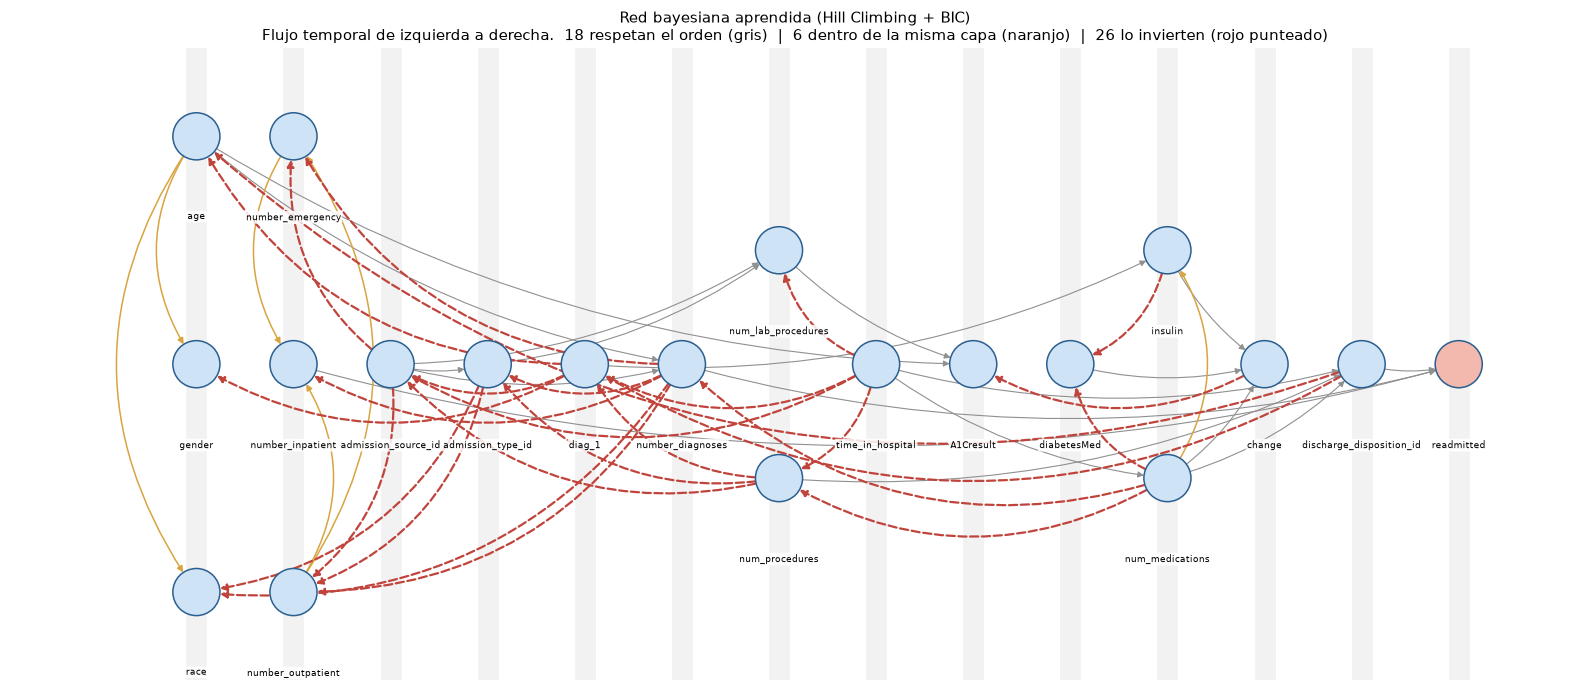

Red bayesiana aprendida (Hill Climbing + BIC): adelante=18  misma_capa=6  atras=26
check_model: True
Padres de readmitted: ['discharge_disposition_id', 'number_diagnoses', 'number_inpatient']


In [ ]:
from pgmpy.estimators import HillClimbSearch

MUESTRA = None 
datos_hc = datos.sample(MUESTRA, random_state=42) if MUESTRA else datos

hc = HillClimbSearch(datos_hc)
dag_aprendido = hc.estimate(scoring_method="bic-d", max_indegree=3,
                            max_iter=int(1e4), show_progress=False)

modelo_aprendido = DiscreteBayesianNetwork(list(dag_aprendido.edges()))
modelo_aprendido.add_nodes_from(VARIABLES_RED)
print("Aristas aprendidas:", modelo_aprendido.number_of_edges())
for a in sorted(modelo_aprendido.edges()):
    print("  ", a[0], "->", a[1])

dibujar_red(modelo_aprendido, "Red bayesiana aprendida (Hill Climbing + BIC)", "red_aprendida.png")

est2 = BayesianEstimator(modelo_aprendido, datos)
modelo_aprendido.add_cpds(*est2.get_parameters(prior_type="BDeu", equivalent_sample_size=10))
print("check_model:", modelo_aprendido.check_model())
print("Padres de readmitted:", sorted(modelo_aprendido.get_parents("readmitted")))

### 6.1 Inferencias sobre la red aprendida

Se repiten exactamente las mismas consultas para que la comparación sea directa.

In [24]:
infer_apr = VariableElimination(modelo_aprendido)
res_apr = {}
for nombre, c in CONSULTAS.items():
    s = consulta(infer_apr, c["objetivo"], c["evidencia"], nombre)
    res_apr[nombre] = s
    print(f"\n[{nombre}] P({c['objetivo']} | {c['evidencia']})")
    print(s.round(4).to_string())

print("\nMarginal de la red aprendida P(readmitted):")
print(consulta(infer_apr, "readmitted", {}, "marginal").round(4).to_string())


[I1] P(readmitted | {'number_inpatient': 'two_plus'})
<30    0.2140
>30    0.4982
NO     0.2878

[I2] P(readmitted | {'number_inpatient': 'zero', 'discharge_disposition_id': 'Home', 'diabetesMed': 'No'})
<30    0.0620
>30    0.2969
NO     0.6411

[I3] P(readmitted | {'discharge_disposition_id': 'Institution', 'number_diagnoses': 'many'})
<30    0.1366
>30    0.3140
NO     0.5494

[I4] P(readmitted | {'age': '[70-100)'})
<30    0.1014
>30    0.3230
NO     0.5756

[I5] P(readmitted | {'diabetesMed': 'Yes', 'number_diagnoses': 'many'})
<30    0.0995
>30    0.3538
NO     0.5467

Marginal de la red aprendida P(readmitted):
<30    0.0907
>30    0.3187
NO     0.5906


### 6.2 Interpretación de las inferencias de la red aprendida

#### Estructura encontrada por el algoritmo

El algoritmo *Hill Climbing* con puntaje BIC discreto produjo una red de 50 aristas frente a las 36 propuestas, con 1.507 parámetros libres contra 906. De las 36 aristas del modelo propuesto, 9 aparecen en el aprendido con la misma dirección y 12 invertidas.

El resultado más relevante se observa en la variable objetivo. La red propuesta le asignaba como nodos padres el conjunto:

$$\{\text{number\_inpatient}, \text{discharge\_disposition\_id}, \text{number\_diagnoses}, \text{diabetesMed}\}$$

El algoritmo recuperó tres de los cuatro padres: $\{\text{number\_inpatient}, \text{discharge\_disposition\_id}, \text{number\_diagnoses}\}$. Además, *readmitted* quedó como nodo hoja en ambas redes (sin hijos), de modo que los mantos de Markov son idénticos salvo por la ausencia de *diabetesMed* en la red aprendida.

Esta convergencia constituye un resultado sustantivo de dos procedimientos independientes, uno basado en conocimiento clínico del dominio y otro en la optimización de un puntaje estadístico sobre 69.970 registros, coinciden en que la readmisión se explica fundamentalmente por la historia de hospitalizaciones previas, el destino al egreso y la carga de comorbilidad. De hecho, las tres aristas que apuntan directamente a *readmitted* figuran entre las 9 que ambas estructuras comparten con idéntica dirección.

La única discrepancia en la variable objetivo se limita a *diabetesMed*. El algoritmo no encontró justificación suficiente en los datos para conservar dicha dependencia directa, ya que la ganancia en verosimilitud no compensaba la penalización del criterio BIC por duplicar el número de configuraciones de la CPD. Esta es una decisión defendible desde la perspectiva de la complejidad del modelo, y plantea la hipótesis de si el efecto del tratamiento farmacológico sobre la readmisión es realmente directo o si queda capturado a través de las otras tres variables.

#### Interpretación de las inferencias

| Consulta | Propuesta $P(\text{<30})$ | Aprendida $P(\text{<30})$ | Diferencia |
| :--- | :---: | :---: | :---: |
| **I1** | 0,2143 | 0,2140 | -0,0003 |
| **I2** | 0,0515 | 0,0620 | +0,0105 |
| **I3** | 0,1349 | 0,1366 | +0,0017 |
| **I4** | 0,0999 | 0,1014 | +0,0015 |
| **I5** | 0,1018 | 0,0995 | -0,0023 |

La distribución marginal de la red aprendida es $P(\text{readmitted} = \text{<30}) = 0,0907$, prácticamente idéntica a la de la red propuesta (0,0899), lo que confirma que ambas estructuras reproducen con precisión la distribución no condicionada de la variable objetivo.

* **Coincidencia en I1, I3 e I4:** 

  Las diferencias en estas consultas son de apenas milésimas, atribuibles al conjunto de aristas auxiliares y no a un desacuerdo sustantivo entre modelos:

  * En **I1**, la evidencia es *number_inpatient*, cuya arista hacia *readmitted* está presente en ambas redes.

  * En **I3**, la evidencia combina *discharge_disposition_id* y *number_diagnoses*, ambas padres en las dos estructuras.

  * En **I4**, la evidencia es *age*, que no es padre directo de *readmitted* en ninguna red, pero mantiene una trayectoria abierta hacia ella (en particular por la arista $age \to number\_diagnoses$, presente en ambos DAGs).

  La conclusión metodológica es clara: cuando dos estructuras comparten la relación estructural relevante, producen inferencias prácticamente idénticas, lo que demuestra que estos efectos son propiedades reales de los datos y no artefactos del diseño del grafo.

* **Divergencia en I2 e I5:** 

  Estas son precisamente las dos consultas que incluyen *diabetesMed* en su evidencia:

  * En **I2** (*diabetesMed* = No), la variable actuaba como factor protector en la red propuesta (elevando la probabilidad de no readmisión). Al desaparecer esa dependencia en la red aprendida, esta no puede aprovechar dicha información y estima un riesgo mayor (0,0620 frente a 0,0515).

  * En **I5** (*diabetesMed* = Yes), la evidencia empujaba el riesgo al alza en el modelo manual. Al perder la arista, la red aprendida estima un riesgo ligeramente menor (0,0995 frente a 0,1018).

  Ambas divergencias apuntan en direcciones opuestas y responden con exactitud a la eliminación de una única arista.

**Efecto del tratamiento farmacológico.** 

El contraste entre I2 e I5 permite cuantificar cuán relevante es la información aportada por *diabetesMed* sobre la red propuesta, la diferencia en $P(\text{<30})$ entre ambos perfiles es de 0,0503, mientras que en la aprendida se reduce a 0,0375. La arista eliminada contribuía, por tanto, con cerca de un cuarto del poder discriminativo entre esos dos perfiles, representando un aporte real pero secundario respecto a los tres padres conservados.

#### Limitaciones causales de la estructura aprendida

A pesar de la coincidencia en el manto de Markov de la variable objetivo, la red aprendida contiene aristas inconsistentes desde el punto de vista causal o temporal:

1. **Inversiones temporales:** Entre las 12 aristas invertidas figuran $diag\_1 \to age$ y $discharge\_disposition\_id \to age$, las cuales sugieren erróneamente que el diagnóstico o el destino al egreso determinan la edad del paciente. Asimismo, $gender \to diag\_1$ aparece en sentido opuesto al causalmente lógico.
2. **Eventos futuros determinando el pasado:** Se aprendieron aristas que parten desde *time_in_hospital* hacia *admission_source_id*, *diag_1*, *num_lab_procedures* y *num_procedures*, implicando que la duración de la estadía determina eventos ocurridos antes o durante el ingreso.

La explicación teórica de este fenómeno es la **equivalencia de Markov** donde dos grafos acíclicos dirigidos (DAG) que codifican el mismo conjunto de independencias condicionales reciben puntajes idénticos bajo la métrica BIC. En consecuencia, la orientación final de las aristas dentro de una misma clase de equivalencia depende del orden de exploración del algoritmo *Hill Climbing* y no de una causalidad presente en los datos. El aprendizaje automático detecta asociaciones estadísticas, pero carece del criterio temporal e institucional que aporta el diseño experto.

## 7. Comparación de ambas redes

In [25]:
from sklearn.model_selection import train_test_split
from pgmpy.metrics import StructureScore, SHD

entren, prueba = train_test_split(datos, test_size=0.25, random_state=42)


def log_verosimilitud(modelo, datos_eval):
    total = np.zeros(len(datos_eval))
    for cpd in modelo.get_cpds():
        var = cpd.variable
        evid = list(cpd.variables[1:])
        vals = cpd.get_values()
        idx = datos_eval[var].map(cpd.name_to_no[var]).to_numpy()
        if evid:
            col = np.zeros(len(datos_eval), dtype=int)
            for e in evid:
                card = cpd.cardinality[cpd.variables.index(e)]
                col = col * card + datos_eval[e].map(cpd.name_to_no[e]).to_numpy()
            p = vals[idx, col]
        else:
            p = vals[idx, 0]
        total += np.log(np.clip(p, 1e-12, None))
    return float(total.sum())


def reajustar(aristas, nodos, datos_fit):
    m = DiscreteBayesianNetwork(list(aristas))
    m.add_nodes_from(nodos)
    m.add_cpds(*BayesianEstimator(m, datos_fit).get_parameters(
        prior_type="BDeu", equivalent_sample_size=10))
    return m


m_prop_tr = reajustar(modelo_propuesto.edges(), VARIABLES_RED, entren)
m_apr_tr = reajustar(modelo_aprendido.edges(), VARIABLES_RED, entren)

scorer_bic = StructureScore(scoring_method="bic-d")
scorer_k2 = StructureScore(scoring_method="k2")

comparacion = pd.DataFrame({
    "propuesta": {
        "n_aristas": modelo_propuesto.number_of_edges(),
        "n_parametros": sum(int((c.cardinality[0] - 1) * np.prod(c.cardinality[1:])) for c in modelo_propuesto.get_cpds()),
        "BIC (todos los datos)": scorer_bic(X=datos, causal_graph=modelo_propuesto),
        "K2 (todos los datos)": scorer_k2(X=datos, causal_graph=modelo_propuesto),
        "logL prueba": log_verosimilitud(m_prop_tr, prueba),
        "logL prueba por fila": log_verosimilitud(m_prop_tr, prueba) / len(prueba),
        "padres de readmitted": len(modelo_propuesto.get_parents("readmitted")),
    },
    "aprendida": {
        "n_aristas": modelo_aprendido.number_of_edges(),
        "n_parametros": sum(int((c.cardinality[0] - 1) * np.prod(c.cardinality[1:])) for c in modelo_aprendido.get_cpds()),
        "BIC (todos los datos)": scorer_bic(X=datos, causal_graph=modelo_aprendido),
        "K2 (todos los datos)": scorer_k2(X=datos, causal_graph=modelo_aprendido),
        "logL prueba": log_verosimilitud(m_apr_tr, prueba),
        "logL prueba por fila": log_verosimilitud(m_apr_tr, prueba) / len(prueba),
        "padres de readmitted": len(modelo_aprendido.get_parents("readmitted")),
    },
})
print("\n", comparacion.round(2).to_string())

a_prop = set(modelo_propuesto.edges())
a_apr = set(modelo_aprendido.edges())
coincidentes = a_prop & a_apr
invertidas = {(u, v) for (u, v) in a_prop if (v, u) in a_apr}
print("\nAristas coincidentes:", len(coincidentes), sorted(coincidentes))
print("\nAristas invertidas:", len(invertidas), sorted(invertidas))
print("\nSolo en la propuesta:", sorted(a_prop - a_apr - invertidas))
print("\nSolo en la aprendida:", sorted(a_apr - a_prop - {(v, u) for (u, v) in invertidas}))
print("\nSHD:", SHD()(true_causal_graph=modelo_propuesto, est_causal_graph=modelo_aprendido))

tabla = pd.concat(
    {"propuesta": pd.DataFrame(res_prop), "aprendida": pd.DataFrame(res_apr)}, axis=1
).round(4)
print("\nInferencias lado a lado:\n", tabla.to_string())


                         propuesta   aprendida
n_aristas                   36.00       50.00
n_parametros               906.00     1507.00
BIC (todos los datos) -1162953.21 -1134219.49
K2 (todos los datos)  -1160856.34 -1130579.63
logL prueba            -289929.30  -282029.17
logL prueba por fila       -16.57      -16.12
padres de readmitted         4.00        3.00

Aristas coincidentes: 9 [('admission_source_id', 'admission_type_id'), ('admission_type_id', 'num_lab_procedures'), ('age', 'number_diagnoses'), ('discharge_disposition_id', 'readmitted'), ('insulin', 'change'), ('number_diagnoses', 'readmitted'), ('number_inpatient', 'readmitted'), ('time_in_hospital', 'discharge_disposition_id'), ('time_in_hospital', 'num_medications')]

Aristas invertidas: 12 [('A1Cresult', 'change'), ('admission_type_id', 'num_procedures'), ('age', 'diag_1'), ('age', 'discharge_disposition_id'), ('diabetesMed', 'insulin'), ('diabetesMed', 'num_medications'), ('diag_1', 'num_procedures'), ('gender', 'd

### 7.1 Análisis comparativo

#### Cómo leer las figuras

Ambas redes se dibujan con los nodos en posiciones idénticas, distribuidos en columnas que corresponden a las capas temporales definidas al diseñar la estructura propuesta. La columna situada más a la izquierda contiene los atributos demográficos, y desde allí se avanza hacia la derecha siguiendo la trayectoria del paciente de la utilización previa del sistema, ingreso, cuadro clínico, proceso hospitalario, manejo farmacológico, egreso y, en el extremo derecho (destacada en otro color), la variable objetivo *readmitted*. Al fijar las posiciones de los nodos en ambas figuras, cualquier diferencia visual entre ellas responde a una diferencia estructural real y no a una disposición arbitraria del grafo.

El color de cada arista codifica su relación con el orden temporal:

* **Gris:** Apuntan hacia la derecha y son compatibles con la cronología de los hechos.
* **Naranja:** Conectan dos variables de una misma columna. Esto no constituye una violación temporal, sino que representa variables coincidentes en el tiempo o cuyo orden relativo no está definido (como los tres contadores de utilización previa, medidos en la misma ventana anual).
* **Rojo punteado:** Apuntan hacia la izquierda, es decir, afirman que un evento posterior influye sobre uno anterior.

Esta codificación convierte la figura en una verificación visual del criterio de diseño. En la red propuesta, las 36 aristas fluyen hacia la derecha sin que aparezca ninguna línea roja, resultado esperable dado que la estructura se construyó imponiendo el orden temporal como restricción. En la red aprendida, en cambio, el color rojo domina la imagen donde 26 de sus 50 aristas apuntan hacia la izquierda. La figura permite así identificar de un vistazo qué relaciones resultan causales e inadmisibles, sin necesidad de revisar la lista de aristas una por una.

#### 1. Estructura

| Métrica | Propuesta | Aprendida |
| :--- | :---: | :---: |
| **Aristas totales** | 36 | 50 |
| **Parámetros libres** | 906 | 1.507 |
| **Padres de *readmitted*** | 4 | 3 |
| **Hijos de *readmitted*** | 0 | 0 |
| **Aristas coincidentes (misma dirección)** | 9 | — |
| **Aristas invertidas** | 12 | — |
| **Distancia Hamming Estructural (SHD)** | 56 | — |

El algoritmo recuperó 21 de las 36 relaciones propuestas si se ignora la dirección (un 58% del esqueleto), lo que confirma que las dependencias identificadas mediante conocimiento del dominio están efectivamente presentes en los datos. De ellas, 9 conservan además la dirección exacta.

Las 9 coincidencias exactas son:

* $admission\_source\_id \to admission\_type\_id$
* $admission\_type\_id \to num\_lab\_procedures$
* $age \to number\_diagnoses$
* $insulin \to change$
* $time\_in\_hospital \to discharge\_disposition\_id$
* $time\_in\_hospital \to num\_medications$
* Las tres aristas que llegan a la variable objetivo: $discharge\_disposition\_id \to readmitted$, $number\_diagnoses \to readmitted$ y $number\_inpatient \to readmitted$.

Que las tres aristas más importantes del modelo las que definen el manto de Markov de *readmitted* figuren entre las coincidencias exactas constituye el resultado estructural más significativo de la comparación.

Las 12 aristas invertidas incluyen casos donde el algoritmo acertó en la asociación pero erró en la orientación (como $A1Cresult \leftrightarrow change$, $diabetesMed \leftrightarrow insulin$ o $num\_procedures \leftrightarrow time\_in\_hospital$), así como casos causalmente inadmisibles ($age \leftrightarrow diag\_1$, $age \leftrightarrow discharge\_disposition\_id$ y $gender \leftrightarrow diag\_1$). La red aprendida se comporta, por tanto, como un modelo de asociación válido pero como un modelo causal inválido, distinción que la red propuesta respeta por construcción.

Las 29 aristas exclusivas de la red aprendida densifican sobre todo el bloque intrahospitalario, conectando *time_in_hospital* hacia atrás con *admission_source_id*, *diag_1*, *num_lab_procedures* y *num_procedures*. Las 15 aristas exclusivas de la propuesta corresponden principalmente a la cascada de manejo de la diabetes y a los efectos de *age* sobre la utilización previa, que el algoritmo reorientó o descartó.

Al contabilizar las aristas respecto del orden temporal:

* **Red propuesta:** 36 hacia adelante, 0 intracapa y 0 hacia atrás.
* **Red aprendida:** 18 hacia adelante, 6 intracapa y 26 que invierten el orden temporal.

Es decir, **más de la mitad de las aristas aprendidas describe una influencia físicamente imposible**, y solo un 36% resulta compatible con la cronología de los hechos. Este contraste resume la limitación central del aprendizaje automático de estructuras donde el algoritmo optimiza el ajuste a la distribución conjunta sin disponer de una noción de precedencia temporal. Las orientaciones producidas dentro de cada clase de equivalencia de Markov son estadísticamente indistinguibles entre sí, pero no equivalentes desde el punto de vista causal.

#### 2. Ajuste a los datos

| Métrica | Propuesta | Aprendida |
| :--- | :---: | :---: |
| **BIC (todos los datos)** | -1.162.953,21 | -1.134.219,49 |
| **K2 (todos los datos)** | -1.160.856,34 | -1.130.579,63 |
| **Log-verosimilitud en prueba** | -289.929,30 | -282.029,17 |
| **Log-verosimilitud por fila** | -16,57 | -16,12 |

La red aprendida supera a la propuesta en las cuatro métricas. La diferencia en BIC es de 28.734 puntos a su favor y en K2 de 30.277. Este comportamiento era esperable, ya que *Hill Climbing* optimiza directamente el puntaje BIC, lo que favorece a la red aprendida por construcción.

El resultado relevante reside en que la ventaja se mantiene en el conjunto de prueba (17.493 filas reservadas que no participaron en la estimación de parámetros) y la red aprendida acumula 7.900 nats más de log-verosimilitud, lo que equivale a 0,45 nats por fila. Dado que ambas redes se ajustaron sobre el mismo conjunto de entrenamiento y se evaluaron sobre la misma prueba, la comparación es totalmente limpia.

Esto permite descartar el sobreajuste (*overfitting*). La red aprendida utiliza un 66% más de parámetros (1.507 frente a 906) y si esa mayor complejidad estuviera memorizando ruido, la log-verosimilitud fuera de muestra habría disminuido. Como la penalización explícita del criterio BIC sobre el número de parámetros sigue favoreciendo a la red aprendida, se concluye que las 29 aristas adicionales capturan dependencias reales en el bloque intrahospitalario que la estructura propuesta había asumido como condicionalmente independientes.

**Ajuste e interpretabilidad no coinciden.** 

La red propuesta es un peor modelo estadístico pero un mejor modelo explicativo donde todas sus aristas admiten una lectura clínica y una dirección defendible, es un 40% más parsimoniosa y su manto de Markov posee significado operativo directo. La red aprendida describe mejor la distribución conjunta, pero incluye relaciones sobre las que no se podría fundamentar una intervención clínica. Por ende, para predecir conviene la red aprendida para explicar el fenómeno.

Cabe precisar que la mejora en el ajuste proviene de las variables intermedias y no de la variable objetivo es que en torno a *readmitted*, ambos modelos son casi idénticos, acumulando las diferencias de log-verosimilitud en nodos como *time_in_hospital*, *diag_1* y *num_procedures*. La red aprendida modela mejor el conjunto de datos global, no la readmisión en sí.

#### 3. Inferencias

| Consulta | Propuesta $P(\text{<30})$ | Aprendida $P(\text{<30})$ | Diferencia |
| :--- | :---: | :---: | :---: |
| **I1** | 0,2143 | 0,2140 | -0,0003 |
| **I2** | 0,0515 | 0,0620 | +0,0105 |
| **I3** | 0,1349 | 0,1366 | +0,0017 |
| **I4** | 0,0999 | 0,1014 | +0,0015 |
| **I5** | 0,1018 | 0,0995 | -0,0023 |

El patrón de inferencia es claro y se explica por completo mediante una sola diferencia estructural:

* **Coincidencia en I1, I3 e I4:** 

  Tres de las cinco consultas coinciden hasta la tercera cifra decimal (diferencias menores a dos milésimas), lo cual resulta notable considerando que las estructuras difieren en 41 aristas y 601 parámetros. Esto ocurre porque toda la evidencia observada en esas tres consultas actúa sobre *readmitted* a través de aristas presentes en ambas redes con la misma dirección. Cuando dos modelos comparten el subgrafo activado por la consulta, producen la misma respuesta probabilística.

* **Divergencia en I2 e I5:** 

  Estas consultas son precisamente las que incorporan *diabetesMed* en su evidencia:

  * En **I2** (*diabetesMed* = No), la red propuesta aprovecha la evidencia como factor protector y reduce el riesgo a 0,0515, mientras que la aprendida, al carecer de la arista, estima un 0,0620.
  * En **I5** (*diabetesMed* = Yes), ocurre lo opuesto: la propuesta sube a 0,1018 y la aprendida se queda en 0,0995.

  Ambas divergencias tienen signos opuestos y son consistentes con la eliminación de esa única arista. En la red aprendida, *diabetesMed* no queda desconectada del todo de la variable objetivo, pero el efecto transmitido por rutas indirectas representa apenas un cuarto del poder discriminativo que producía la dependencia directa.

* **Capacidad de discriminación entre perfiles:** 

  La razón entre el perfil de mayor riesgo (I3) y el de menor riesgo (I2) es de 2,62 en la red propuesta y de 2,20 en la aprendida. Ambos modelos discriminan bien los extremos, pero la propuesta lo logra con mayor solidez gracias a la arista adicional.

En síntesis, las dos redes coinciden exactamente donde comparten estructura y divergen allí donde su topología difiere, sin ninguna divergencia inexplicada. Este comportamiento da la validez de ambos modelos de la inferencia probabilística responde estrictamente a lo predicho por la topología del grafo.

## 8. Conclusiones respecto a la Parte 1

Se construyeron dos redes bayesianas sobre 69.970 registros y 20 variables del conjunto *Diabetes 130-US Hospitals*, con *readmitted* como variable objetivo.

La red propuesta se diseñó imponiendo el orden temporal de la trayectoria del paciente, criterio que garantizó la aciclicidad por construcción y permitió justificar la dirección de cada una de sus 36 aristas. Su manto de Markov para la variable objetivo formado por *number_inpatient*, *discharge_disposition_id*, *number_diagnoses* y *diabetesMed* resultó tener una lectura clínica coherente y se verificó numéricamente que al fijar esas cuatro variables y agregar *age* o *diag_1* como evidencia adicional no altera la distribución resultante.

La red aprendida mediante el algoritmo *Hill Climbing* y el puntaje BIC recuperó 21 de las 36 aristas propuestas y coincidió en tres de los cuatro padres de la variable objetivo, resultando en mantos de Markov prácticamente idénticos. Superó a la propuesta en las cuatro métricas de ajuste, incluida la log-verosimilitud sobre el conjunto de prueba reservado, con una ventaja de 0,45 nats por fila que descarta el sobreajuste (*overfitting*). Sin embargo, esta mejora proviene del ajuste de las variables intermedias y no del nodo objetivo: en torno a *readmitted*, ambos modelos son prácticamente equivalentes.

La convergencia entre el diseño basado en conocimiento del dominio y el algoritmo de optimización de verosimilitud constituye el resultado del ejercicio. Que dos procedimientos independientes identifiquen las mismas tres variables como determinantes clave de la readmisión otorga confiabilidad en que se trata de una propiedad de los datos y no de un sesgo de modelado.

El costo de dicha mejora en el ajuste estadístico es la pérdida de interpretabilidad. La red aprendida contiene aristas físicamente o temporalmente imposibles (como $diag\_1 \to age$ o $time\_in\_hospital \to admission\_source\_id$), consecuencia de que las métricas basadas en verosimilitud no distinguen entre DAG pertenecientes a la misma clase de equivalencia de Markov. Un algoritmo de aprendizaje de estructura recupera asociaciones probabilísticas pero no relaciones causales, al carecer del ordenamiento temporal explícito que aporta el conocimiento humano.

La comparación de inferencias confirmó que ambos modelos coinciden en sus predicciones allí donde comparten topología y divergen únicamente donde difieren. Como conclusión sustantiva del dominio, la historia de hospitalizaciones previas (*number_inpatient*) se consolida como el predictor más robusto de readmisión, al multiplicar por 2,39 la probabilidad de reingreso temprano y constituir el único efecto directo que ambas estructuras reproducen de forma prácticamente idéntica.

Por lo tanto, el ejercicio demuestra que ambas aproximaciones son complementarias. El aprendizaje automático de estructuras resulta valido para descubrir dependencias no contempladas en el diseño manual, mientras que el conocimiento del dominio es para orientar causalmente las aristas y obtener un modelo explicativo sobre el cual fundamentar decisiones. 